In [1]:
from scipy.interpolate import RectBivariateSpline, interp1d
import numpy as np
from cosmopower import cosmopower_NN
import os
import matplotlib.pyplot as plt
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

In [2]:
omega0=0.31
k = np.logspace(-3, 1, 128)

a=1.
w0=-1.
wa=0.
omegaL = (1.-omega0) * a**(-3.*(1.+w0+wa)) * np.exp(3.*(-1.+a)*wa)
omegaL0 = (1.-omega0) 
E = np.sqrt(omega0/a**3 + omegaL)

mu0=0.33

In [3]:
def mu_DE_a(a, mu0, c1, lamb):
    omegaL = (1.-omega0) * a**(-3.*(1.+w0+wa)) * np.exp(3.*(-1.+a)*wa)
    omegaL0 = (1.-omega0) 
    E = np.sqrt(omega0/a**3 + omegaL)
    return 1. + mu0*(omegaL/E**2)/omegaL0*((1+c1*(lamb*E/k)**2)/(1.+(lamb*E/k)**2))
h0 = 1./2997.92458
def mu_DE_a_DESI(a, mu0, c1, lamb):
    omegaL = (1.-omega0) * a**(-3.*(1.+w0+wa)) * np.exp(3.*(-1.+a)*wa)
    omegaL0 = (1.-omega0) 
    E = np.sqrt(omega0/a**3 + omegaL)
    return 1. + mu0*(omegaL/E**2)/omegaL0*((1+c1*(lamb*h0*E/k)**2)/(1.+(lamb*h0*E/k)**2))

(0.001, 10)

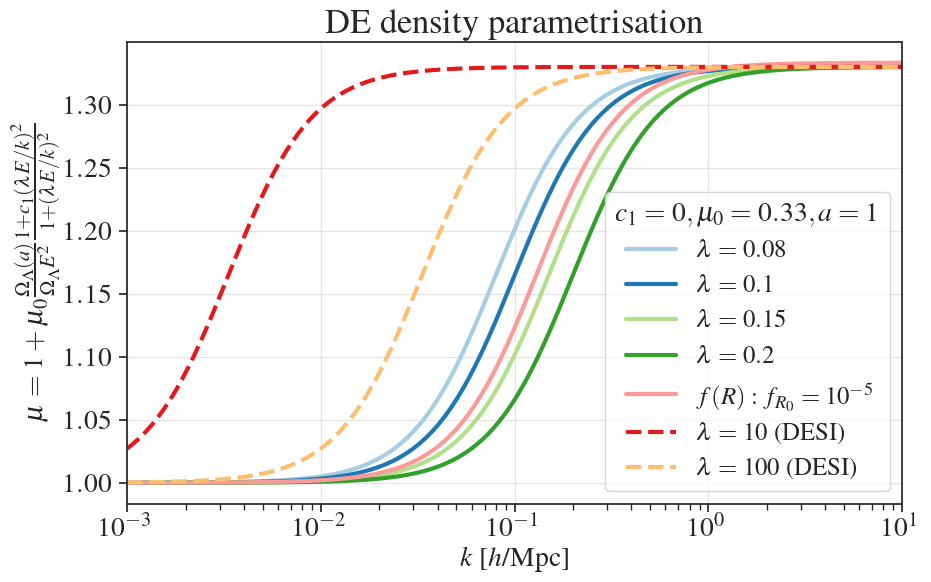

In [6]:
c1 = 0.0
mu_DE = lambda lamb: 1. + mu0*(omegaL/E**2)/omegaL0*((1+c1*(lamb*E/k)**2)/(1.+(lamb*E/k)**2))
var1 = (k/a)**2
h0 = 1./2997.92458
fR0 = 10**(-5.)
mu_fofR = 1. + var1/(3.*(var1+(omega0/a**3-4.*(omega0-1.))**3/(2.*fR0/h0**2*(4.-3.*omega0)**2)));
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', sharex=True, sharey=True)
#ax.semilogx(k, mu_DE(0.08), label='$\\lambda=0.08$')
ax.semilogx(k, mu_DE_a(1, 0.33, 0.0, 0.08), label='$\\lambda=0.08$')
ax.semilogx(k, mu_DE(0.1), label='$\\lambda=0.1$')
ax.semilogx(k, mu_DE(0.15), label='$\\lambda=0.15$')
ax.semilogx(k, mu_DE(0.2), label='$\\lambda=0.2$')
ax.semilogx(k, mu_fofR, label='$f(R): f_{R_0}=10^{-5}$')
ax.semilogx(k, mu_DE_a_DESI(1, 0.33, 0.0, 10.), label='$\\lambda=10$ (DESI)', ls='--')
ax.semilogx(k, mu_DE_a_DESI(1, 0.33, 0.0, 100.), label='$\\lambda=100$ (DESI)', ls='--')
ax.legend(title='$c_1=0, \\mu_0=0.33, a=1$', title_fontsize=20)
ax.set_xlabel('$k$ [$h$/Mpc]')
ax.set_ylabel('$\\mu=1+\\mu_0\\frac{\\Omega_\Lambda(a)}{\\Omega_\Lambda E^2}\\frac{1+c_1(\\lambda E/k)^2}{1+(\\lambda E/k)^2}$')
ax.set_title('DE density parametrisation')
ax.grid(alpha=0.5)
ax.set_xlim(0.001, 10)

(0.001, 10)

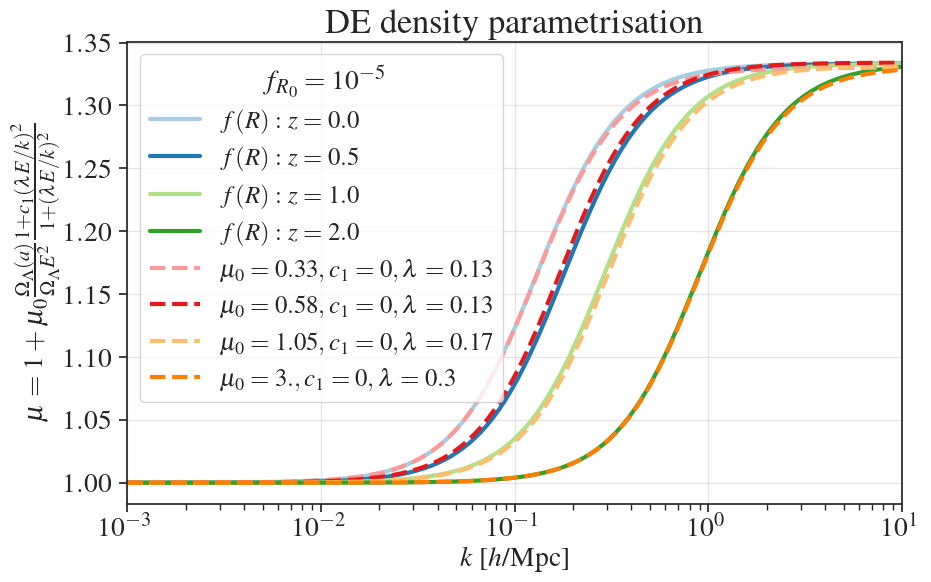

In [68]:
zz = np.array([0., 0.5, 1., 2.])
aa = 1./(1.+zz)
var1 = (k/a)**2
h0 = 1./2997.92458
fR0 = 10**(-5.)
mu_fofR = lambda a_i: 1. + 1./3*var1/(var1+(omega0/a_i**3-4.*(omega0-1.))**3/(2.*fR0/h0**2*(4.-3.*omega0)**2))
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', sharex=True, sharey=True)
for i in range(len(aa)):
    ax.semilogx(k, mu_fofR(aa[i]), label='$f(R): z={:.1f}$'.format(zz[i]))
ax.semilogx(k, mu_DE_a(aa[0], 0.33, 0.0, 0.13), label='$\\mu_0=0.33, c_1=0, \\lambda=0.13$', linestyle='--')
ax.semilogx(k, mu_DE_a(aa[1], 0.58, 0.0, 0.13), label='$\\mu_0=0.58, c_1=0, \\lambda=0.13$', linestyle='--')
ax.semilogx(k, mu_DE_a(aa[2], 1.05, 0.0, 0.17), label='$\\mu_0=1.05, c_1=0, \\lambda=0.17$', linestyle='--')
ax.semilogx(k, mu_DE_a(aa[3], 3., 0.0, 0.3), label='$\\mu_0=3., c_1=0, \\lambda=0.3$', linestyle='--')
ax.legend(title='$f_{R_0}=10^{-5}$', title_fontsize=20)
ax.set_xlabel('$k$ [$h$/Mpc]')
ax.set_ylabel('$\\mu=1+\\mu_0\\frac{\\Omega_\Lambda(a)}{\\Omega_\Lambda E^2}\\frac{1+c_1(\\lambda E/k)^2}{1+(\\lambda E/k)^2}$')
ax.set_title('DE density parametrisation')
ax.grid(alpha=0.5)
ax.set_xlim(0.001, 10)